In [1]:
import numpy as np
from src.graphs import generate_points, show_plot
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd

In [2]:
def generate_connection_matrix(points: list, simplices: list) -> list[np.ndarray, np.ndarray, np.ndarray]:
    connections = np.zeros((npoints, npoints))
    weights = np.zeros((npoints, npoints))
    distance = np.zeros((npoints, npoints))
    paths = []
    for tr in simplices:
        for i in range(3):
            for j in range(3):
                if i == j:
                    connections[tr[i]][tr[j]] = 1
                    continue
                connections[tr[i]][tr[j]] = 2
                length = np.linalg.norm(points[tr[i]] - points[tr[j]])
                distance[tr[i]][tr[j]] = length
                weights[tr[i]][tr[j]] = np.pow(length, -1)
                paths.append([tr[i], tr[j]])
    
    connections = connections - np.ones_like(connections)

    return connections, weights, distance

In [3]:
def generate_pheromone_matrix(npoints: int, weights: np.ndarray) -> np.ndarray:
    tau = np.ones((npoints, npoints))
    adj_tau = tau * weights
    norm = np.sum(np.concatenate(adj_tau))
    if norm == 0:
        return -1
    return adj_tau / norm

In [4]:
def find_length(path: list, 
                distance: np.ndarray) -> float:
    L = 0
    for i in range(len(path)-1):
        L += distance[i, i+1]
    return L

In [5]:
def simplify_path(path: list) -> list:
    changed = True
    while changed:
        changed = False
        seen: dict = {}
        for i, v in enumerate(path):
            if v in seen:
                path = np.concatenate([path[:seen[v]+1], path[i + 1:]])
                changed = True
                break
            seen[v] = i
    return path


In [6]:
def choose_next_from_current(current: int,
                neighbours: list,
                pheromone: np.ndarray,
                weight_matrix: np.ndarray,
                alpha: float = 1,
                beta: float  = 1) -> int:
    scores = np.array([
        (weight_matrix[current][k] ** alpha) * (pheromone[current][k] ** beta)
        for k in neighbours
    ])

    total = scores.sum()
    if total == 0:
        return random.choice(neighbours)

    probs = scores / total
    return int(np.random.choice(neighbours, p=probs))

In [7]:
def update_pheromones(phermone: np.ndarray,
               paths: np.ndarray,
               dist_mat: np.ndarray,
               alpha: float = 1.,
               beta: float = 1.,
               Q: float = 1,
               rho: float = 0.5,) -> np.ndarray:
    phermone *= (1 - rho)
    for path in paths:
        L = find_length(path, dist_mat)
        delta = Q/L
        for k in range(len(path) - 1):
            i, j = path[k], path[k+1]
            phermone[i][j] == delta
            phermone[j][i] == delta
    return phermone

In [8]:
def ant_walk(start: int, end: int,
             conn: np.ndarray,
             pheromone: np.ndarray,
             weight_matrix: np.ndarray,
             alpha: float = 1.,
             beta: float  = 1.,
             max_steps: int = None) -> list:
    n = len(conn)
    if max_steps is None:
        max_steps = n * 4

    path    = [start]
    current = start

    for _ in range(max_steps):
        if current == end:
            break
        neighbours = [k for k in range(n) if conn[current][k] == 1]
        if not neighbours:
            break
        nxt = choose_next_from_current(current, neighbours, pheromone, weight_matrix, alpha, beta)
        path.append(nxt)
        current = nxt

    return simplify_path(path)

In [40]:
def aco(start: int, end: int,
        conn: np.ndarray,
        dist_matrix: np.ndarray,
        weight_matrix: np.ndarray,
        alpha: float = 1., beta: float = 1., rho: float = 0.5,
        n_ants: int = 10, n_iter: int = 40) -> tuple:
    
    n = len(conn)
    pheromone = generate_pheromone_matrix(n, weight_matrix)

    best_path   = None
    best_length = float('inf')
    history     = []
    for it in range(n_iter):
        successful_paths = []

        for _ in range(n_ants):
            path = ant_walk(start, end, conn, pheromone, weight_matrix, alpha, beta)
            #print(path)
            if path[-1] == end:
                successful_paths.append(path)
                L = find_length(path, dist_matrix)
                if L < best_length:
                    best_length = round(L,2)
                    best_path   = path[:]

        if successful_paths:
            pheromone = update_pheromones(pheromone, successful_paths, dist_matrix, rho)

        history.append(best_length)

    print(f"ACO {start}→{end}: path = {best_path}, len = {best_length:.3f}")

    return best_path, best_length

In [41]:
def aco_multi_target(waypoints: list,
                     conn: np.ndarray,
                     dist_matrix: np.ndarray,
                     weight_matrix: np.ndarray,
                     alpha: float = 1., beta: float = 1., rho: float = 0.5,
                     n_ants: int = 10, n_iter: int = 40) -> tuple:
    full_path    = []
    total_length = 0.0

    for i in range(len(waypoints) - 1):
        seg_start = waypoints[i]
        seg_end   = waypoints[i + 1]
        seg_path, seg_len = aco(seg_start, seg_end,
                                conn, dist_matrix, weight_matrix,
                                alpha, beta, rho, n_ants, n_iter)
        if seg_path is None:
            print(f"Could not find path from {seg_start} to {seg_end}!")
            return None, float('inf')
            
        if len(full_path) != 0:
            full_path.extend(seg_path[1:])
        else:
            full_path.extend(seg_path)

        total_length += seg_len

    print(f"  Full path : {full_path}")
    print(f"  Total len : {total_length:.3f}")
    return full_path, total_length



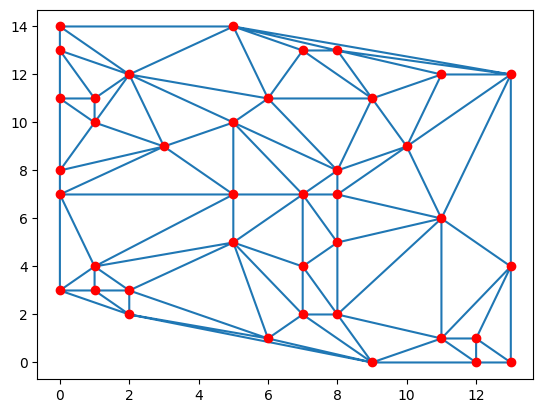

In [47]:
npoints = 40
p, s = generate_points(npoints)
connections, weights, distance = generate_connection_matrix(p, s)
show_plot(p, s)

ACO 0→23: path = [ 0  1 15 13 16 19 23], len = 11.000


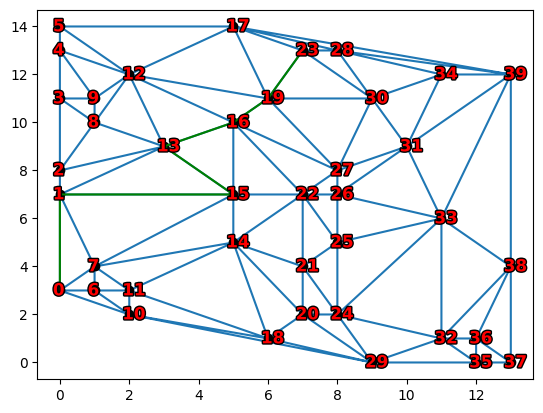

In [58]:
path, lentgth = aco(0, 23, connections, distance, weights)
plt.figure()
plt.triplot(p[:, 0], p[:, 1], s)
plt.plot(p[path, 0], p[path, 1], color='g')
plt.scatter(p[:, 0], p[:, 1], color='black')
for i, (x, y) in enumerate(p):
    plt.text(x - 0.2, y - 0.2, str(i), fontsize=12, fontweight='bold', color='r', path_effects=[pe.withStroke(linewidth=2, foreground='black')])
plt.savefig("graph_with_path.png")

ACO 0→38: path = [ 0 10 29 32 38], len = 10.000
ACO 38→20: path = [38, 32, 24, 20], len = 8.000
  Full path : [np.int64(0), np.int64(10), np.int64(29), np.int64(32), np.int64(38), 32, 24, 20]
  Total len : 18.000


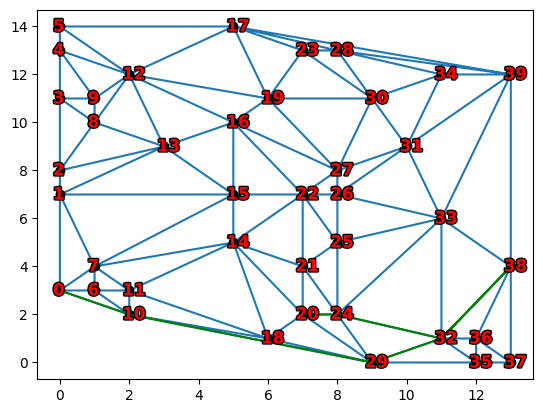

In [54]:
mul_path, mul_length = aco_multi_target([0, 38, 20], connections, distance, weights)
plt.figure()
plt.triplot(p[:, 0], p[:, 1], s)
plt.plot(p[mul_path, 0], p[mul_path, 1], color='g')
plt.scatter(p[:, 0], p[:, 1], color='black')
for i, (x, y) in enumerate(p):
    plt.text(x - 0.2, y - 0.2, str(i), fontsize=12, fontweight='bold', color='r', path_effects=[pe.withStroke(linewidth=2, foreground='black')])
plt.savefig("graph_with_mul_path.png")